In [1]:
import pandas as pd 

In [2]:
import numpy as np

In [4]:
greed = pd.read_csv("fear_greed_index.csv")

In [6]:
historical = pd.read_csv("historical_data.csv")

In [14]:
historical.sample(9)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
2959,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,26.41000,151.66000,4005.34,BUY,17-02-2025 08:54,3.426552e+04,Buy,0.000000,0xfb5346bf23f4087d22e7041de8302d01ba00fb33a967...,72797988288,True,0.050958,2.580000e+14,1.740000e+12
158694,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,24.38000,13.11000,319.62,SELL,16-12-2024 10:37,4.038033e+04,Sell,69.804957,0x00000000000000000000000000000000000000000000...,55711525523,False,0.015981,4.440000e+14,1.730000e+12
70894,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,17.55700,291.56000,5118.92,SELL,05-03-2025 04:20,2.073913e+05,Close Long,274.678676,0x2736d438dca701290379041eeaf04f01f700e371e5bb...,77211119412,True,1.535675,5.410000e+13,1.740000e+12
112603,0x8477e447846c758f5a675856001ea72298fd9cb5,kPEPE,0.00842,65914.00000,555.00,BUY,23-04-2025 01:32,-1.115392e+07,Close Short,-11.403122,0x5988875770c9da20c2a304220d472b0201d900453f3e...,88095068638,False,0.055499,1.110000e+15,1.750000e+12
6935,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,85033.00000,0.95581,81275.39,SELL,16-04-2025 21:42,5.496640e+00,Close Long,499.028401,0x71d72a1d7ab8f7a961a60421aa5b980185009c0bd1ef...,86974982935,True,18.693340,1.020000e+15,1.740000e+12
50463,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,DOGE,0.25335,3916.00000,992.12,BUY,21-02-2025 11:04,-4.546480e+05,Close Short,21.283460,0x1c87017883e084d866ae041e2acf770201f600b83ea1...,73785508048,True,0.347241,1.080000e+15,1.740000e+12
132904,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,STRK,0.69180,144.40000,99.90,BUY,09-12-2024 18:05,-6.518000e+02,Close Short,6.119672,0x8165f1fe8591f09b8d800418ce7f5802017b00fa76a4...,53893470310,True,0.034963,2.440000e+14,1.730000e+12
57308,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,HYPE,16.97000,12.76000,216.54,BUY,18-04-2025 04:21,-2.300000e+03,Close Short,1.047596,0x71b8ef34eab8c6abce0d0421bf145401d30001fc3b5d...,87246472583,True,0.075788,6.690000e+14,1.740000e+12
137947,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,PENDLE,3.56440,20.00000,71.29,SELL,24-01-2025 01:57,3.110000e+02,Close Long,0.274540,0xae847c21c23822020c21041c4576bb02016b002f92f2...,66010500225,True,0.024950,9.900000e+14,1.740000e+12


In [15]:
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
greed.sample(9)

,timestamp,value,classification,date
1459,1643779800,28,Fear,2022-02-02
650,1573882200,41,Fear,2019-11-16
852,1591335000,53,Neutral,2020-06-05
1739,1667971800,29,Fear,2022-11-09
316,1545024600,17,Extreme Fear,2018-12-17
1910,1682746200,64,Greed,2023-04-29
2541,1737351000,76,Extreme Greed,2025-01-20
320,1545370200,35,Fear,2018-12-21
1740,1668058200,22,Extreme Fear,2022-11-10


In [11]:
greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

## EDA (let's Explor our data )

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

## Scatter Plot (For better UnderStanding)

In [86]:
# Convert to datetime
historical['date'] = pd.to_datetime(historical['Timestamp']).dt.floor('D')
greed['date'] = pd.to_datetime(greed['timestamp']).dt.floor('D')

# specify the unit since pandas assumed nanoseconds, not seconds
greed['timestamp'] = pd.to_datetime(greed['timestamp'], unit='s')

In [87]:
# Normalize to Same Time Scale 
historical['date'] = historical['date'].dt.normalize()
greed['date'] = greed['date'].dt.normalize()

In [88]:
greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   datetime64[ns]
 1   value           2644 non-null   int32         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int32(1), object(1)
memory usage: 72.4+ KB


In [89]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float32       
 3   Size Tokens       211224 non-null  float32       
 4   Size USD          211224 non-null  float32       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float32       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float32       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int32         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float32       
 14  Trad

 ### merged = pd.merge(historical, greed[['date', 'classification']], on='date',how='left')

## since it was consuming too much memory 
     29 GiB (not good)

## Keep Latest Value Per Day

In [91]:
greed = greed.sort_values('timestamp')

greed_daily = greed.groupby('date').last().reset_index()

In [92]:
print(greed_daily['date'].duplicated().sum())
print(greed_daily.shape)

0
(1, 4)


In [93]:
merged = pd.merge(
    historical,
    greed_daily[['date', 'classification']],
    on='date',
    how='left'
)

In [94]:
print(merged.shape)
print(merged['classification'].isnull().sum())
print(merged['classification'].value_counts())

(211224, 18)
0
classification
Greed    211224
Name: count, dtype: int64


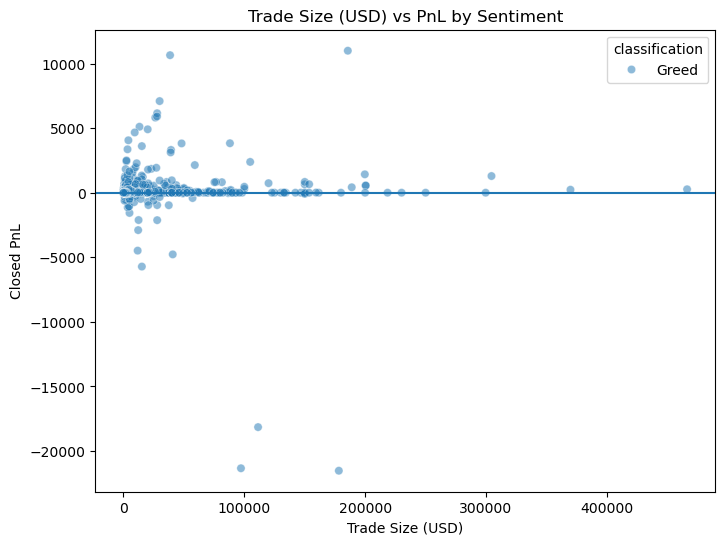

In [95]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged.sample(5000),
    x='Size USD',
    y='Closed PnL',
    hue='classification',
    alpha=0.5
)

plt.axhline(0)
plt.title("Trade Size (USD) vs PnL by Sentiment")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")
plt.show()

### Observations:
    Most trades, regardless of size, result in near-zero PnL.
    Increasing trade size does not guarantee higher profit.
    A few large profits exist, but they are rare outliers.
    Large trades often show inefficient returns or small gains.

In [96]:
merged['is_profit'] = (merged['Closed PnL'] > 0).astype(int)
merged['abs_pnl'] = merged['Closed PnL'].abs()

In [97]:
merged['size_category'] = pd.cut(
    merged['Size USD'],
    bins=[0, 1000, 10000, 100000, 1000000],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

In [98]:
merged['direction_encoded'] = merged['Direction'].map({
    'BUY': 1,
    'SELL': -1
})

In [99]:
merged['hour'] = merged['Timestamp'].dt.hour
merged['day'] = merged['Timestamp'].dt.day_name()

## Sentiment

In [100]:
merged.groupby('classification')['is_profit'].mean()

classification
Greed    0.411265
Name: is_profit, dtype: float64

In [101]:
## Avg PnL by Size Category

merged.groupby('size_category')['Closed PnL'].mean()

C:\Windows\Temp\ipykernel_36968\1824891992.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby('size_category')['Closed PnL'].mean()


size_category
Small           6.620593
Medium         52.686329
Large         266.530334
Very Large    779.289795
Name: Closed PnL, dtype: float32

## Sentiment vs Trade Size

In [102]:
merged.groupby('classification')['Size USD'].mean()

classification
Greed    5639.451172
Name: Size USD, dtype: float32

In [103]:
## Profit vs Direction
merged.groupby('Direction')['Closed PnL'].mean()

Direction
Auto-Deleveraging             7184.806641
Buy                              0.000000
Close Long                      74.426422
Close Short                    103.012810
Liquidated Isolated Short   -12752.913086
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053085
Settlement                     -29.215368
Short > Long                   154.190399
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float32

<Axes: xlabel='classification', ylabel='Closed PnL'>

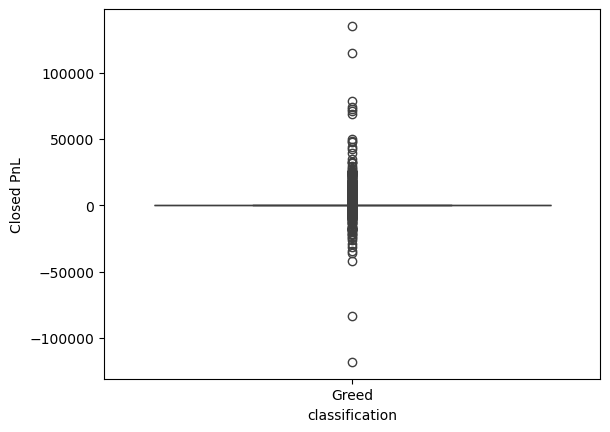

In [104]:
sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

## Insight Note
    The PnL distribution is heavily concentrated around zero, indicating most trades yield minimal profit or loss.
    There are significant outliers on both positive and negative sides, showing occasional large gains and losses.
    The spread is very wide, indicating high variability and risk in trading outcomes.
    Extreme negative values suggest potential liquidation or poor risk management.

## Conclusion:
    Trader performance is highly volatile, with most trades being neutral and a few extreme outcomes driving overall results.

In [105]:
merged['classification'].value_counts()

classification
Greed    211224
Name: count, dtype: int64

In [106]:
print(greed['timestamp'].min())
print(greed['timestamp'].max())
print(greed['timestamp'].nunique())

1970-01-01 00:00:01.517463
1970-01-01 00:00:01.746163800
2644


In [107]:
greed['timestamp'].head(10)

0   1970-01-01 00:00:01.517463000
1   1970-01-01 00:00:01.517549400
2   1970-01-01 00:00:01.517635800
3   1970-01-01 00:00:01.517722200
4   1970-01-01 00:00:01.517808600
5   1970-01-01 00:00:01.517895000
6   1970-01-01 00:00:01.517981400
7   1970-01-01 00:00:01.518067800
8   1970-01-01 00:00:01.518154200
9   1970-01-01 00:00:01.518240600
Name: timestamp, dtype: datetime64[ns]